In [2]:
from google.colab import files
files.upload()

Saving kaggle (3).json to kaggle (3).json


{'kaggle (3).json': b'{"username":"saishanthv","key":"92599c1d7c47b4d7821dabdd345c4a7c"}'}

In [3]:
!pip install kaggle

In [8]:
import os
os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [7]:
!mv "kaggle (3).json" kaggle.json

In [9]:
!kaggle datasets download -d mlg-ulb/creditcardfraud

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
  0% 0.00/66.0M [00:00<?, ?B/s]
100% 66.0M/66.0M [00:00<00:00, 1.53GB/s]


In [10]:
import zipfile
with zipfile.ZipFile("creditcardfraud.zip","r") as zip_ref:
  zip_ref.extractall("fraud_data")

In [11]:
import pandas as pd
df = pd.read_csv("fraud_data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [13]:
df.shape

(284807, 31)

In [14]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [15]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [17]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [18]:
fraud_percentage = (df['Class'].sum() / len(df)) * 100
print("Fraud Percentage:", fraud_percentage)

Fraud Percentage: 0.1727485630620034


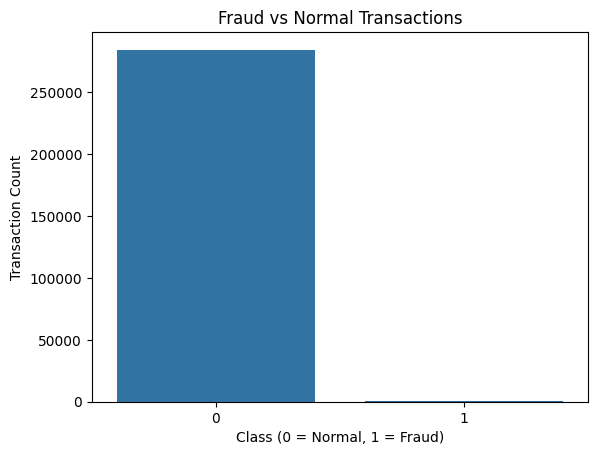

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Transaction Count")
plt.show()

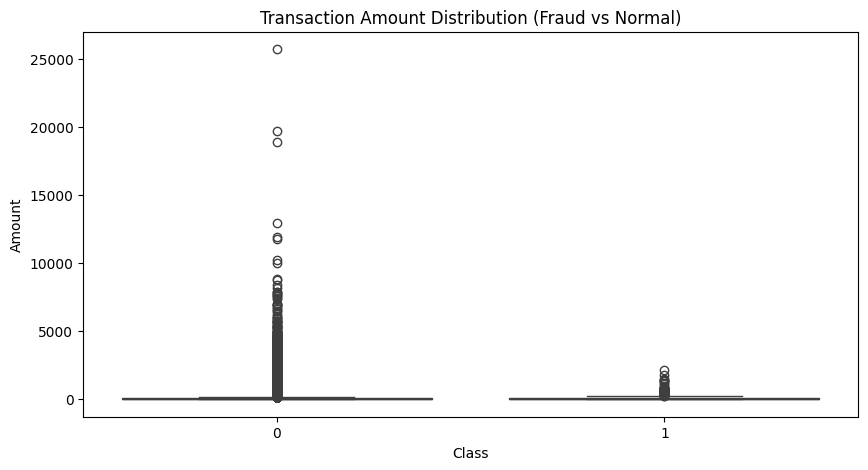

In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Transaction Amount Distribution (Fraud vs Normal)")
plt.show()

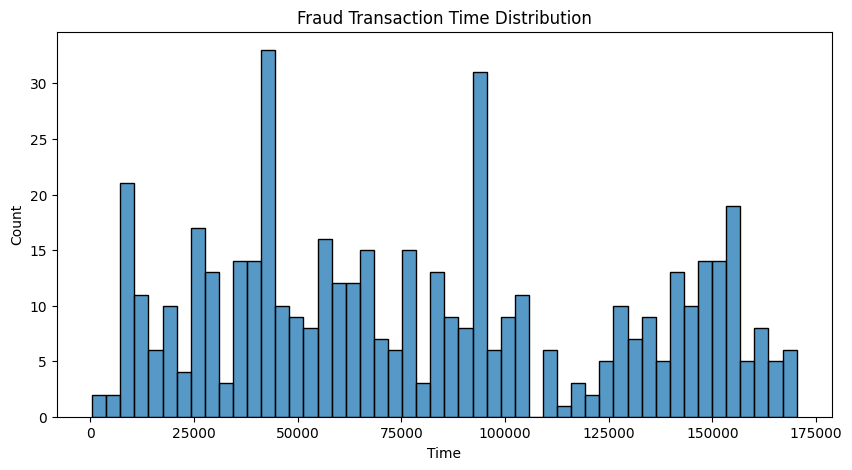

In [21]:
plt.figure(figsize=(10,5))
sns.histplot(df[df['Class']==1]['Time'], bins=50)
plt.title("Fraud Transaction Time Distribution")
plt.show()

In [22]:
X = df.drop("Class", axis=1)
y=df["Class"]
print(X.shape)
print(y.shape)

(284807, 30)
(284807,)


In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)

(227845, 30)
(56962, 30)


In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train["Amount"] = scaler.fit_transform(X_train[["Amount"]])
X_test["Amount"] = scaler.transform(X_test[["Amount"]])

In [25]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

In [26]:
y_pred = log_model.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9737193216530319

Confusion Matrix:
[[55375  1489]
 [    8    90]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [28]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [29]:
y_pred_rf = rf_model.predict(X_test)

In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9995259997893332

Confusion Matrix:
[[56861     3]
 [   24    74]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962



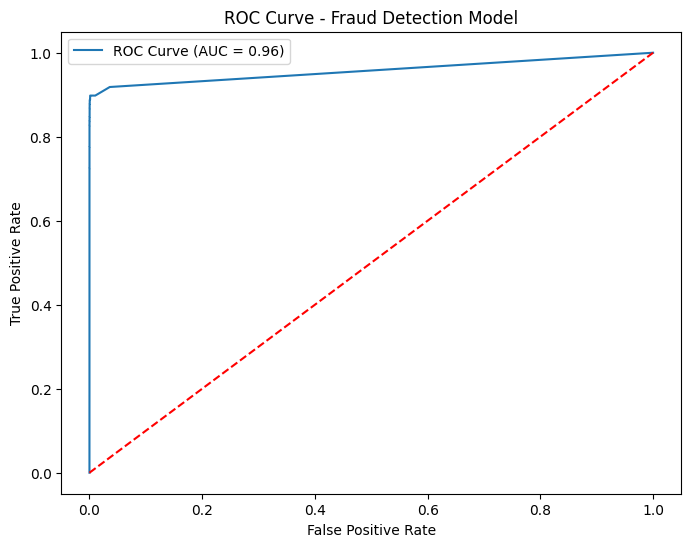

In [31]:
from sklearn.metrics import roc_curve, auc
y_prob = rf_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Fraud Detection Model")
plt.legend()
plt.show()

In [32]:
import pandas as pd
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
importance.head(10)

,0
V14,0.172755
V4,0.115382
V10,0.111231
V12,0.093417
V17,0.092719
V3,0.064234
V11,0.058795
V16,0.051311
V2,0.028824
V7,0.025840


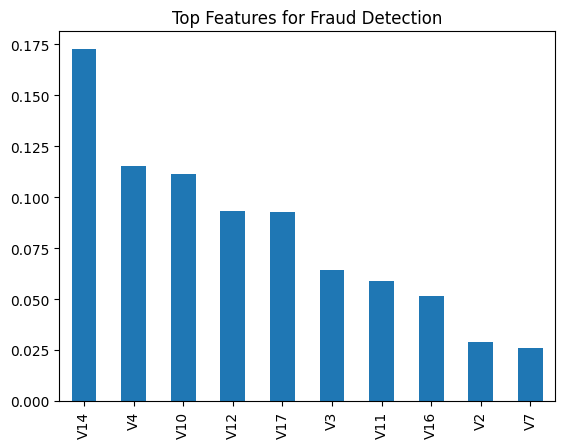

In [33]:
importance.head(10).plot(kind="bar")
plt.title("Top Features for Fraud Detection")
plt.show()

In [34]:
y_prob = rf_model.predict_proba(X_test)[:,1]
print(y_prob[:10])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [35]:
fraud_results = X_test.copy()
fraud_results["actual_class"] = y_test.values
fraud_results["fraud_probability"] = y_prob
fraud_results.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,actual_class,fraud_probability
263020,160760.0,-0.674466,1.408105,-1.110622,-1.328366,1.388996,-1.308439,1.885879,-0.614233,0.311652,...,0.810034,-0.224327,0.707899,-0.135837,0.045102,0.533837,0.291319,-0.259954,0,0.0
11378,19847.0,-2.829816,-2.765149,2.537793,-1.074580,2.842559,-2.153536,-1.795519,-0.250020,3.073504,...,0.109305,-0.813272,0.042996,-0.027660,-0.910247,0.110802,-0.511938,-0.304426,0,0.0
147283,88326.0,-3.576495,2.318422,1.306985,3.263665,1.127818,2.865246,1.444125,-0.718922,1.874046,...,0.016867,-0.132058,-1.483996,-0.296011,0.062823,0.552411,0.509764,-0.048286,0,0.0
219439,141734.0,2.060386,-0.015382,-1.082544,0.386019,-0.024331,-1.074935,0.207792,-0.338140,0.455091,...,-0.639426,0.331818,-0.067584,-0.283675,0.203529,-0.063621,-0.060077,-0.347741,0,0.0
36939,38741.0,1.209965,1.384303,-1.343531,1.763636,0.662351,-2.113384,0.854039,-0.475963,-0.629658,...,-0.328294,-0.154631,0.619449,0.818998,-0.330525,0.046884,0.104527,-0.345707,0,0.0


In [36]:
fraud_results["risk_score"] = (fraud_results["fraud_probability"] * 100).round(2)
fraud_results[["fraud_probability","risk_score"]].head()

,fraud_probability,risk_score
263020,0.0,0.0
11378,0.0,0.0
147283,0.0,0.0
219439,0.0,0.0
36939,0.0,0.0


In [37]:
def risk_band(prob):
    if prob < 0.20:
        return "Low Risk"
    elif prob < 0.60:
        return "Medium Risk"
    else:
        return "High Risk"
fraud_results["risk_band"] = fraud_results["fraud_probability"].apply(risk_band)
fraud_results["risk_band"].value_counts()

,count
risk_band,
Low Risk,56866
High Risk,73
Medium Risk,23


In [38]:
def fraud_decision(prob):
    if prob < 0.20:
        return "Approve Transaction"
    elif prob < 0.60:
        return "Flag for Review"
    else:
        return "Block Transaction"
fraud_results["decision"] = fraud_results["fraud_probability"].apply(fraud_decision)
fraud_results[["fraud_probability","risk_band","decision"]].head(10)

,fraud_probability,risk_band,decision
263020,0.0,Low Risk,Approve Transaction
11378,0.0,Low Risk,Approve Transaction
147283,0.0,Low Risk,Approve Transaction
219439,0.0,Low Risk,Approve Transaction
36939,0.0,Low Risk,Approve Transaction
243438,0.0,Low Risk,Approve Transaction
259448,0.0,Low Risk,Approve Transaction
43800,0.0,Low Risk,Approve Transaction
66742,0.0,Low Risk,Approve Transaction
66499,0.0,Low Risk,Approve Transaction


In [39]:
fraud_summary = fraud_results.groupby("risk_band").agg(
    transactions=("risk_band","count"),
    avg_risk_score=("risk_score","mean"),
    actual_fraud_rate=("actual_class","mean")
).reset_index()
fraud_summary

,risk_band,transactions,avg_risk_score,actual_fraud_rate
0,High Risk,73,89.452055,0.972603
1,Low Risk,56866,0.034150,0.000264
2,Medium Risk,23,36.478261,0.521739


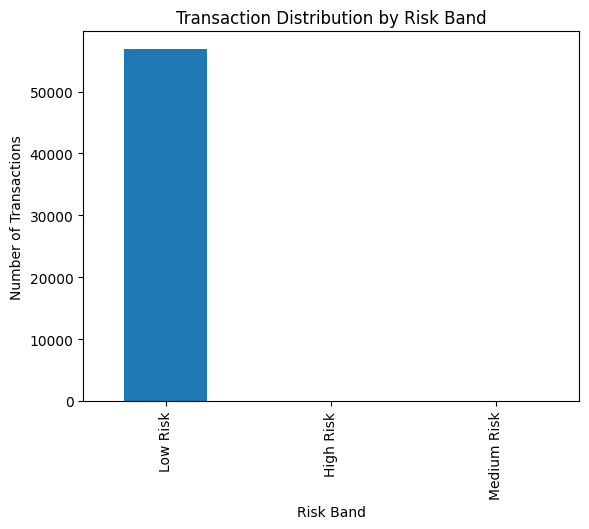

In [40]:
import matplotlib.pyplot as plt
fraud_results["risk_band"].value_counts().plot(kind="bar")
plt.title("Transaction Distribution by Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Number of Transactions")
plt.show()

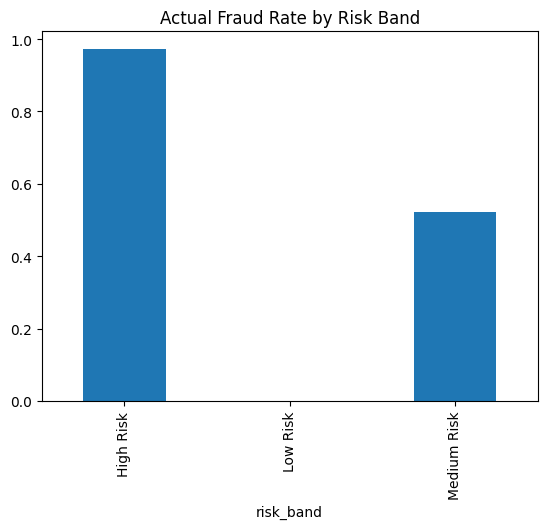

In [41]:
fraud_rate = fraud_results.groupby("risk_band")["actual_class"].mean()
fraud_rate.plot(kind="bar")
plt.title("Actual Fraud Rate by Risk Band")
plt.show()

In [42]:
fraud_results.to_csv("fraud_detection_predictions.csv", index=False)
fraud_summary.to_csv("fraud_risk_summary.csv", index=False)
print("Fraud scoring datasets exported.")

Fraud scoring datasets exported.


In [43]:
dashboard_fraud_data = fraud_results[[
    "Amount",
    "fraud_probability",
    "risk_score",
    "risk_band",
    "decision",
    "actual_class"
]].copy()
dashboard_fraud_data.to_csv("fraud_dashboard_data.csv", index=False)
dashboard_fraud_data.head()

,Amount,fraud_probability,risk_score,risk_band,decision,actual_class
263020,-0.259954,0.0,0.0,Low Risk,Approve Transaction,0
11378,-0.304426,0.0,0.0,Low Risk,Approve Transaction,0
147283,-0.048286,0.0,0.0,Low Risk,Approve Transaction,0
219439,-0.347741,0.0,0.0,Low Risk,Approve Transaction,0
36939,-0.345707,0.0,0.0,Low Risk,Approve Transaction,0


In [44]:
from google.colab import files
files.download("fraud_detection_predictions.csv")
files.download("fraud_risk_summary.csv")
files.download("fraud_dashboard_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>